# Stage 4 — Feature Extraction
## Spam Comment Detector — Thesis Project

**The core problem:** Machine learning models are mathematical functions.
They multiply numbers, compute dot products, and calculate distances.
They cannot do any of this with raw strings like `"join casino get free spin"`.

We need to convert our text into numbers. This conversion is called **feature extraction** (or **vectorization**).

**Two approaches we will compare:**

| Method | Core Idea | Produced by |
|---|---|---|
| **Bag of Words (BoW)** | Count how many times each word appears in a document | `CountVectorizer` |
| **TF-IDF** | Weight word counts by how rare the word is across all documents | `TfidfVectorizer` |

**What you will learn in this notebook:**
1. What a feature matrix is and why text must become numbers
2. How Bag of Words works (with a tiny hand-built example)
3. How TF-IDF improves on BoW
4. How to use scikit-learn's `CountVectorizer` and `TfidfVectorizer`
5. How to split data into training and test sets
6. Why the train/test split must happen **before** vectorization (data leakage)
7. How to inspect the feature matrix and vocabulary

**Input:**  `data/processed/comments_clean.csv`
**Output:** Feature matrices `X_train`, `X_test` and labels `y_train`, `y_test`

## Section 1 — Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

DATA_IN = os.path.join('..', 'data', 'processed', 'comments_clean.csv')

print("Libraries loaded.")
print("scikit-learn vectorizers: CountVectorizer, TfidfVectorizer")


Libraries loaded.
scikit-learn vectorizers: CountVectorizer, TfidfVectorizer


## Section 2 — Load Cleaned Data

In [3]:
df = pd.read_csv(DATA_IN)

print(f"Loaded: {DATA_IN}")
print(f"Shape : {df.shape}")
print(f"Labels: {df['label'].value_counts().to_dict()}")
print()
print(df.head(6).to_string(index=False))


Loaded: ..\data\processed\comments_clean.csv
Shape : (80, 2)
Labels: {'ham': 40, 'spam': 40}

                                 comment label
great video realli help understand topic   ham
                make tutori python decor   ham
                      exactli look thank   ham
             ive watch time alreadi help   ham
               could explain part recurs   ham
                 amaz content alway keep   ham


## Section 3 — Understanding Bag of Words

Before using scikit-learn, let's build Bag of Words **by hand** on a tiny example so you understand exactly what it does.

**The idea:** Imagine you have a vocabulary (a fixed list of all known words).
For each document, you count how many times each vocabulary word appears.
The result is a vector of counts — one number per word.

This is called "Bag of Words" because you throw all words into a bag and count them,
losing any information about word order. Order doesn't matter — just presence and frequency.

In [4]:
# Three tiny documents
docs = [
    "casino free spin",          # spam
    "great video tutorial",      # ham
    "free casino bonus win",     # spam
]

# Step 1: Build the vocabulary — every unique word, sorted alphabetically
vocab = sorted(set(w for doc in docs for w in doc.split()))
print("Vocabulary (all unique words across all documents):")
print(f"  {vocab}\n")

# Step 2: For each document, count how many times each vocab word appears
print(f"{'Document':<25}", end='')
for v in vocab:
    print(f"{v:>10}", end='')
print()
print('-' * (25 + 10 * len(vocab)))

bow_matrix = []
for doc in docs:
    word_list = doc.split()
    row = [word_list.count(v) for v in vocab]
    bow_matrix.append(row)
    print(f"{doc!r:<25}", end='')
    for count in row:
        print(f"{count:>10}", end='')
    print()

print()
print("Each ROW is a document represented as a vector of word counts.")
print("Each COLUMN is a vocabulary word (a 'feature').")
print(f"\nMatrix shape: {len(bow_matrix)} documents x {len(vocab)} features")


Vocabulary (all unique words across all documents):
  ['bonus', 'casino', 'free', 'great', 'spin', 'tutorial', 'video', 'win']

Document                      bonus    casino      free     great      spin  tutorial     video       win
---------------------------------------------------------------------------------------------------------
'casino free spin'                0         1         1         0         1         0         0         0
'great video tutorial'            0         0         0         1         0         1         1         0
'free casino bonus win'           1         1         1         0         0         0         0         1

Each ROW is a document represented as a vector of word counts.
Each COLUMN is a vocabulary word (a 'feature').

Matrix shape: 3 documents x 8 features


## Section 4 — Understanding TF-IDF

**The problem with raw counts:**
A word like "free" that appears in every spam comment gets a high count —
but so does a word like "the" that appears everywhere including ham.
Raw counts don't reward words that are *distinctive* to a class.

**TF-IDF solves this** by multiplying two scores:

- **TF (Term Frequency):** How often does this word appear *in this document*?
  `TF = count of word in document / total words in document`

- **IDF (Inverse Document Frequency):** How *rare* is this word across *all* documents?
  `IDF = log(total documents / documents containing this word)`

A word that appears in every document gets IDF ≈ 0 (it's useless for distinguishing classes).
A word that appears in only 1 document gets a high IDF (it's very distinctive).

**TF-IDF = TF × IDF**

Words that are frequent *within* a document AND rare *across* documents get the highest score.

In [5]:
import math

# Using the same tiny 3-document corpus from Section 3
print("TF-IDF demonstration on the same 3-document corpus\n")
print(f"Corpus: {docs}\n")

N = len(docs)  # total number of documents

for word in vocab:
    # How many documents contain this word?
    df_word = sum(1 for doc in docs if word in doc.split())

    # IDF: log((1 + N) / (1 + df)) + 1    <- scikit-learn's smoothed formula
    idf = math.log((1 + N) / (1 + df_word)) + 1

    print(f"  '{word}':  appears in {df_word}/{N} docs  ->  IDF = {idf:.4f}")

print()
print("Notice:")
print("  'casino' and 'free' appear in 2/3 docs  -> moderate IDF")
print("  'bonus', 'great', 'tutorial', 'video', 'win'")
print("  appear in only 1/3 docs -> higher IDF (more distinctive)")


TF-IDF demonstration on the same 3-document corpus

Corpus: ['casino free spin', 'great video tutorial', 'free casino bonus win']

  'bonus':  appears in 1/3 docs  ->  IDF = 1.6931
  'casino':  appears in 2/3 docs  ->  IDF = 1.2877
  'free':  appears in 2/3 docs  ->  IDF = 1.2877
  'great':  appears in 1/3 docs  ->  IDF = 1.6931
  'spin':  appears in 1/3 docs  ->  IDF = 1.6931
  'tutorial':  appears in 1/3 docs  ->  IDF = 1.6931
  'video':  appears in 1/3 docs  ->  IDF = 1.6931
  'win':  appears in 1/3 docs  ->  IDF = 1.6931

Notice:
  'casino' and 'free' appear in 2/3 docs  -> moderate IDF
  'bonus', 'great', 'tutorial', 'video', 'win'
  appear in only 1/3 docs -> higher IDF (more distinctive)


## Section 5 — Train/Test Split

Before we vectorize the full dataset, we must **split it** into:
- **Training set** (80%): The model learns patterns from this data
- **Test set** (20%): We evaluate the model on data it has NEVER seen

### Why split BEFORE vectorizing?

This is one of the most important rules in ML: **never let test data influence training**.

If we vectorized the whole dataset first and *then* split:
- The vocabulary would include words from test comments
- The IDF scores would be influenced by test counts
- The model would have "seen" information from the test set during training

This is called **data leakage** — the model appears to perform better than it really would on new data.

**Correct order:** split first → fit vectorizer on train only → transform both train and test.

In [6]:
X = df['comment']   # text features (Series of strings)
y = df['label']     # labels: 'ham' or 'spam'

# train_test_split parameters:
#   test_size=0.2   -> 20% goes to test set (16 rows), 80% to train (64 rows)
#   random_state=42 -> fixes the random seed so results are reproducible
#   stratify=y      -> ensures the split preserves the ham/spam ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Test split complete.")
print(f"  Total  : {len(X)} samples")
print(f"  Train  : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test   : {len(X_test)}  samples ({len(X_test)/len(X)*100:.0f}%)")
print()
print("Label distribution in each split (stratify=y ensures balance):")
print(f"  Train: {y_train.value_counts().to_dict()}")
print(f"  Test : {y_test.value_counts().to_dict()}")


Train/Test split complete.
  Total  : 80 samples
  Train  : 64 samples (80%)
  Test   : 16  samples (20%)

Label distribution in each split (stratify=y ensures balance):
  Train: {'spam': 32, 'ham': 32}
  Test : {'ham': 8, 'spam': 8}


## Section 6 — Bag of Words with CountVectorizer

`CountVectorizer` from scikit-learn does exactly what we did by hand in Section 3 — but for all 64 training documents and their full vocabulary.

Two steps:
1. **`.fit(X_train)`** — learn the vocabulary from training data only
2. **`.transform(X)`** — convert any text into a count vector using that vocabulary

These are always done **separately** for train and test for exactly the reason explained in Section 5.

In [7]:
# Create the vectorizer
# min_df=1 means include words that appear in at least 1 document (default, keeps all words)
bow_vectorizer = CountVectorizer(min_df=1)

# Fit on training data ONLY — this builds the vocabulary
bow_vectorizer.fit(X_train)

# Transform both splits using the vocabulary learned from training
X_train_bow = bow_vectorizer.transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

vocab = bow_vectorizer.get_feature_names_out()

print("Bag of Words vectorization complete.")
print(f"  Vocabulary size : {len(vocab)} unique words")
print(f"  X_train_bow shape: {X_train_bow.shape}  (64 documents x {len(vocab)} features)")
print(f"  X_test_bow  shape: {X_test_bow.shape}   (16 documents x {len(vocab)} features)")
print()
print(f"Matrix type: {type(X_train_bow)}")
print("(Sparse matrix — stores only non-zero values to save memory)")
print()

# Show a slice of the feature matrix as a DataFrame for readability
sample_df = pd.DataFrame(
    X_train_bow[:5].toarray(),
    columns=vocab
)
# Show only columns that have at least one non-zero value in the first 5 rows
nonzero_cols = sample_df.columns[sample_df.sum() > 0]
print("First 5 training rows — non-zero columns only:")
print(sample_df[nonzero_cols].to_string())


Bag of Words vectorization complete.
  Vocabulary size : 247 unique words
  X_train_bow shape: (64, 247)  (64 documents x 247 features)
  X_test_bow  shape: (16, 247)   (16 documents x 247 features)

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
(Sparse matrix — stores only non-zero values to save memory)

First 5 training rows — non-zero columns only:
   anywher  best  bet  casino  channel  comment  compar  dailybetxxxcom  day  diamondslot  everi  first  free  keep  learn  new  note  onlin  pdf  regist  rewatch  section  sign  tech  thing  third  time  version  wholesom
0        0     1    1       1        0        0       0               0    0            1      0      1     1     0      0    0     0      1    0       1        0        0     0     0      0      0     0        0         0
1        1     0    0       0        0        0       0               0    0            0      0      0     0     0      0    0     1      0    1       0        0        0     0     0      0   

## Section 7 — TF-IDF with TfidfVectorizer

Now we apply the same process using TF-IDF weights instead of raw counts.
The API is identical — `fit` then `transform` — making it easy to swap methods.

In [8]:
tfidf_vectorizer = TfidfVectorizer(min_df=1)

tfidf_vectorizer.fit(X_train)

X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF vectorization complete.")
print(f"  X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"  X_test_tfidf  shape: {X_test_tfidf.shape}")
print()

# Compare BoW vs TF-IDF for the SAME first training document
first_doc = X_train.iloc[0]
print(f"Document: {first_doc!r}\n")

bow_row   = X_train_bow[0].toarray()[0]
tfidf_row = X_train_tfidf[0].toarray()[0]
vocab_arr = bow_vectorizer.get_feature_names_out()

# Show only the words that are actually present in this document
present = [(vocab_arr[i], int(bow_row[i]), round(tfidf_row[i], 4))
           for i in range(len(vocab_arr)) if bow_row[i] > 0]

print(f"{'Word':<18} {'BoW count':>12} {'TF-IDF score':>14}")
print('-' * 46)
for word, bow_val, tfidf_val in present:
    print(f"  {word:<16} {bow_val:>12} {tfidf_val:>14.4f}")
print()
print("Notice: TF-IDF scores are decimal values, not raw counts.")
print("Words that are rarer across the corpus get higher TF-IDF scores.")


TF-IDF vectorization complete.
  X_train_tfidf shape: (64, 247)
  X_test_tfidf  shape: (16, 247)

Document: 'best onlin casino diamondslot first bet free regist'

Word                  BoW count   TF-IDF score
----------------------------------------------
  best                        1         0.3948
  bet                         1         0.2993
  casino                      1         0.3225
  diamondslot                 1         0.4670
  first                       1         0.3715
  free                        1         0.2570
  onlin                       1         0.3225
  regist                      1         0.3525

Notice: TF-IDF scores are decimal values, not raw counts.
Words that are rarer across the corpus get higher TF-IDF scores.


## Section 8 — Visualise Top Features by TF-IDF Score

Which words are most important for distinguishing spam from ham?
We can answer this by looking at the **mean TF-IDF score** per word for each class.
A high mean score means that word consistently appears and is distinctive within that class.

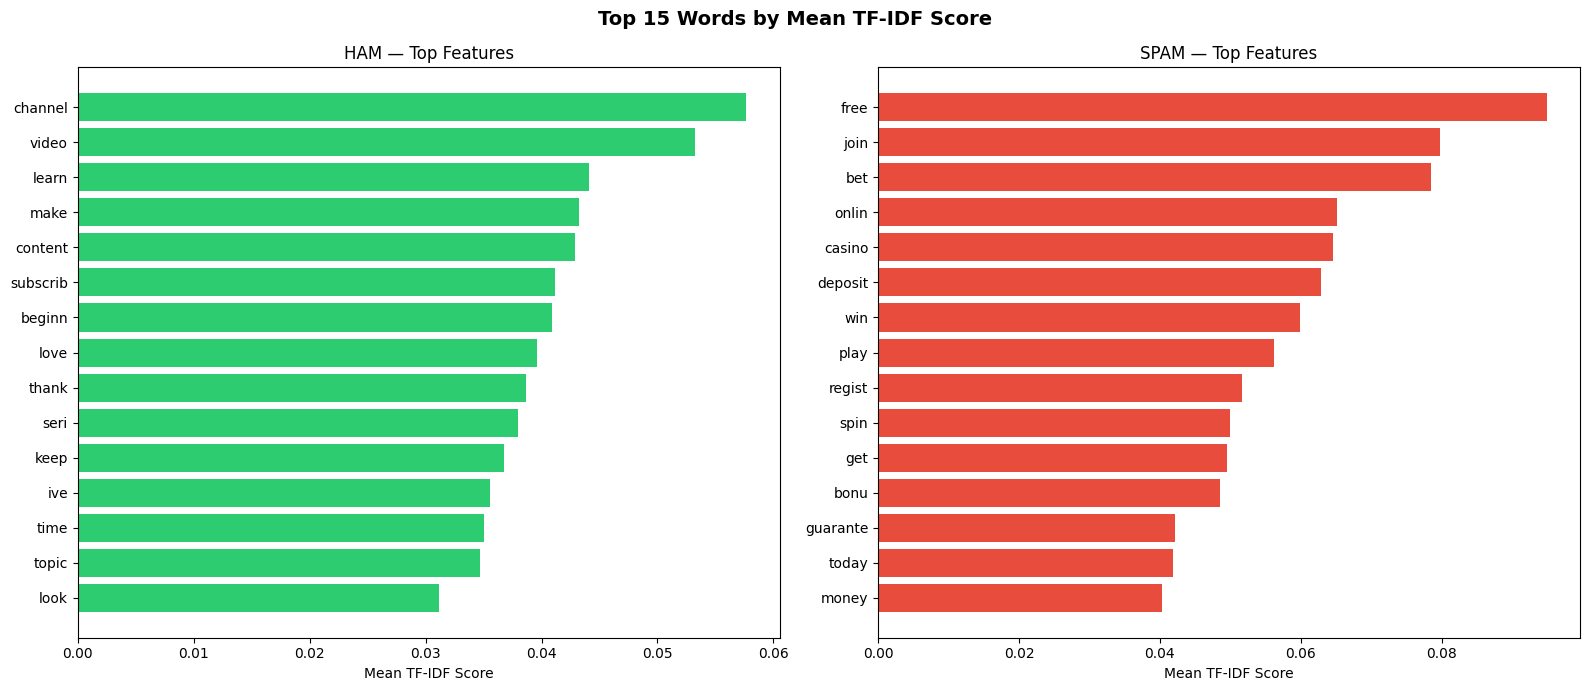


These are the words with the highest mean TF-IDF scores in each class.
The classifier will use these as the strongest signals for prediction.


In [9]:
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert sparse matrices to dense arrays
tfidf_dense = X_train_tfidf.toarray()
labels_arr  = y_train.values

# Separate ham and spam rows
ham_mask  = labels_arr == 'ham'
spam_mask = labels_arr == 'spam'

# Mean TF-IDF score per word for each class
ham_mean  = tfidf_dense[ham_mask].mean(axis=0)
spam_mean = tfidf_dense[spam_mask].mean(axis=0)

TOP_N = 15

# Top features for ham
ham_top_idx  = ham_mean.argsort()[::-1][:TOP_N]
spam_top_idx = spam_mean.argsort()[::-1][:TOP_N]

ham_top_words   = [feature_names[i] for i in ham_top_idx]
ham_top_scores  = [ham_mean[i]      for i in ham_top_idx]
spam_top_words  = [feature_names[i] for i in spam_top_idx]
spam_top_scores = [spam_mean[i]     for i in spam_top_idx]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Top {TOP_N} Words by Mean TF-IDF Score", fontsize=14, fontweight='bold')

ax1.barh(range(TOP_N), ham_top_scores[::-1], color='#2ecc71')
ax1.set_yticks(range(TOP_N))
ax1.set_yticklabels(ham_top_words[::-1])
ax1.set_xlabel('Mean TF-IDF Score')
ax1.set_title('HAM — Top Features')

ax2.barh(range(TOP_N), spam_top_scores[::-1], color='#e74c3c')
ax2.set_yticks(range(TOP_N))
ax2.set_yticklabels(spam_top_words[::-1])
ax2.set_xlabel('Mean TF-IDF Score')
ax2.set_title('SPAM — Top Features')

plt.tight_layout()
plt.show()

print("\nThese are the words with the highest mean TF-IDF scores in each class.")
print("The classifier will use these as the strongest signals for prediction.")


## Section 9 — Matrix Sparsity

A key property of text feature matrices is **sparsity**: most entries are zero because
each document only uses a small fraction of the total vocabulary.

Sparse matrices store only the non-zero values — otherwise our 64×297 matrix
would waste most of its memory on zeros.

Feature matrix dimensions : 64 rows x 247 columns
Total cells               : 15,808
Non-zero cells            : 418
Zero cells                : 15,390
Sparsity                  : 97.4% of values are zero



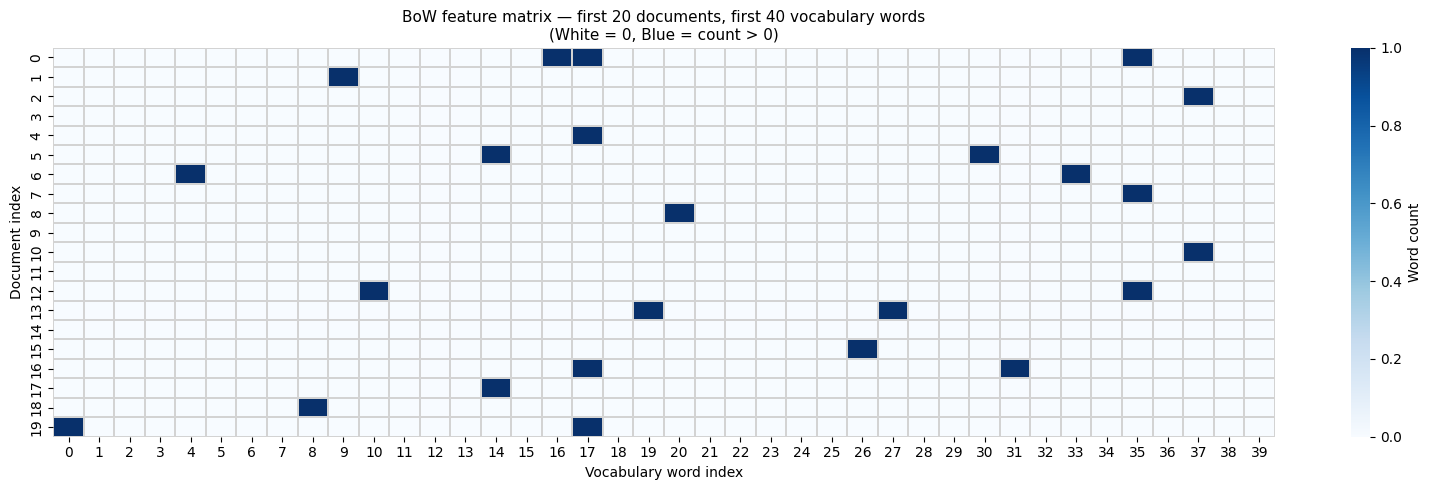

Most cells are white (zero) — only a few words appear in each document.


In [10]:
total_cells  = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero      = X_train_tfidf.nnz
sparsity_pct = (1 - nonzero / total_cells) * 100

print(f"Feature matrix dimensions : {X_train_tfidf.shape[0]} rows x {X_train_tfidf.shape[1]} columns")
print(f"Total cells               : {total_cells:,}")
print(f"Non-zero cells            : {nonzero:,}")
print(f"Zero cells                : {total_cells - nonzero:,}")
print(f"Sparsity                  : {sparsity_pct:.1f}% of values are zero")
print()

# Visualise: show the BoW matrix as a heatmap (first 20 docs, first 40 features)
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    X_train_bow[:20, :40].toarray(),
    cmap='Blues',
    linewidths=0.3,
    linecolor='lightgrey',
    cbar_kws={'label': 'Word count'},
    ax=ax
)
ax.set_title('BoW feature matrix — first 20 documents, first 40 vocabulary words\n'
             '(White = 0, Blue = count > 0)', fontsize=11)
ax.set_xlabel('Vocabulary word index')
ax.set_ylabel('Document index')
plt.tight_layout()
plt.show()

print(f"Most cells are white (zero) — only a few words appear in each document.")


## Section 10 — Stage 4 Summary

In [11]:
print("=" * 60)
print("  FEATURE EXTRACTION SUMMARY — Stage 4 Complete")
print("=" * 60)
print(f"  Total samples        : {len(df)}")
print(f"  Training samples     : {len(X_train)}  (80%)")
print(f"  Test samples         : {len(X_test)}   (20%)")
print(f"  Vocabulary size      : {len(feature_names)} unique words")
print(f"  Matrix sparsity      : {sparsity_pct:.1f}%")
print()
print("  Feature matrices produced:")
print(f"    X_train_bow   : {X_train_bow.shape}")
print(f"    X_test_bow    : {X_test_bow.shape}")
print(f"    X_train_tfidf : {X_train_tfidf.shape}")
print(f"    X_test_tfidf  : {X_test_tfidf.shape}")
print()
print("  Ready for Stage 5 — Model Training!")
print("  We will train classifiers on these feature matrices and")
print("  compare Naive Bayes, Logistic Regression, and SVM.")


  FEATURE EXTRACTION SUMMARY — Stage 4 Complete
  Total samples        : 80
  Training samples     : 64  (80%)
  Test samples         : 16   (20%)
  Vocabulary size      : 247 unique words
  Matrix sparsity      : 97.4%

  Feature matrices produced:
    X_train_bow   : (64, 247)
    X_test_bow    : (16, 247)
    X_train_tfidf : (64, 247)
    X_test_tfidf  : (16, 247)

  Ready for Stage 5 — Model Training!
  We will train classifiers on these feature matrices and
  compare Naive Bayes, Logistic Regression, and SVM.
